## 데이터 타입 변환 & 결측치 처리 기초

In [2]:
import pandas as pd

# 예시 데이터프레임 생성
data = pd.DataFrame({
    'A':['1','2','3'],
    'B':['4','5','6'],
    'C':['7','8','9'],
})
data

,A,B,C
0,1,4,7
1,2,5,8
2,3,6,9


### apply(pd.to_numeric)
- 선택한 여러 열에 숫자 변환 함수를 일괄 적용한다.

In [5]:
# 데이터 타입을 int로 변경
data = data[['A','B','C']].apply(pd.to_numeric)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       3 non-null      int64
 1   B       3 non-null      int64
 2   C       3 non-null      int64
dtypes: int64(3)
memory usage: 204.0 bytes


In [6]:
pd.__version__

'3.0.3'

## dropna()
- 결측 값이 있는 행 제거
- 가장 간단하지만 데이터가 많이 삭제될 수 있어 신중하게 사용해야 한다.
- 결측치 비율이 매우 낮을 때만 권장한다.
- 기본값은 행 기준
- axis = 1 --> 열 기준 

In [8]:
data = pd.DataFrame({
    'A':['1','2','3',None],
    'B':['4',None,'5','6'],
    'C':[None,'7','8','9'],
})
data

,A,B,C
0,1,4,NaN
1,2,NaN,7
2,3,5,8
3,NaN,6,9


In [9]:
data.dropna()

,A,B,C
2,3,5,8


In [11]:
data_dropna = data.dropna()

In [12]:
data_dropna

,A,B,C
2,3,5,8


In [13]:
data

,A,B,C
0,1,4,NaN
1,2,NaN,7
2,3,5,8
3,NaN,6,9


In [14]:
data_dropna_col = data.dropna(axis=1)
data_dropna_col

""
0
1
2
3


## fillna(다른 값)
- 결측치를 다른 값으로 채운다.

## 결측값을 0으로 채우기
- 행이 삭제되지 않아 데이터 손실은 없지만, 0이라는 값의 실제 의미가 작용할 때는 혼동될 수 있다.

In [17]:
data.fillna(0)

,A,B,C
0,1,4,0
1,2,0,7
2,3,5,8
3,0,6,9


In [18]:
data_fillna0 = data.fillna(0)

data_fillna0

,A,B,C
0,1,4,0
1,2,0,7
2,3,5,8
3,0,6,9


## 결측값을 평균으로 채우기 - fillna(mean())
- mean() 평균
- 숫자형 데이터 (나이, 온도, 점수 등)에서 가장 널리 쓰이는 결측치 처리 방식
- 극단적인 이상치가 있으면 평균이 왜곡될 수 있으니, 이상치 제거 후 평균을 채우는 순서가 안전하다.

In [21]:
data_numeric = data[['A','B','C']].apply(pd.to_numeric)

In [22]:
data_numeric.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       3 non-null      float64
 1   B       3 non-null      float64
 2   C       3 non-null      float64
dtypes: float64(3)
memory usage: 228.0 bytes


In [24]:
data_numeric.mean() # 각 컬럼별 평균

A    2.0
B    5.0
C    8.0
dtype: float64

In [26]:
data_numeric = data_numeric.fillna(data_numeric.mean())

## 결측값을 최빈값으로 채우기

## 최빈값 : mode()
- 해당 열에서 가장 자주 나온 값들을 리스트형태로 변환
- 최빈값이 여러개 여도 첫번째 값 불러오기 --> [0]

In [28]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       3 non-null      str  
 1   B       3 non-null      str  
 2   C       3 non-null      str  
dtypes: str(3)
memory usage: 228.0 bytes


In [29]:
mode_a = data['A'].mode()

mode_a

0    1
1    2
2    3
Name: A, dtype: str

In [30]:
mode_a[0]

'1'

In [31]:
mode_b = data['B'].mode()

mode_b

0    4
1    5
2    6
Name: B, dtype: str

In [32]:
mode_c = data['C'].mode()

mode_c

0    7
1    8
2    9
Name: C, dtype: str

In [33]:
data['A'].fillna(mode_a[0])

0    1
1    2
2    3
3    1
Name: A, dtype: str

In [ ]:
data.apply(lambda x: x.fillna(x.mode()[0])) # 데이터 프레임의 열마다 같은 코드를 반복 적용시킬 때

,A,B,C
0,1,4,7
1,2,4,7
2,3,5,8
3,1,6,9


In [35]:
# lambda 매개변수 : 함수 몸통(리턴값)
f = lambda x: x + 1 # 매개변수 x에 +1을 한다.

f(2)

3

## 열마다 다른 값으로 결측치 대체 (딕셔너리 활용)
- 열마다 성격이 다를때 사용
- 성별은 최빈값, 지역은 '기타'

In [40]:
data2 = pd.DataFrame({
    '성별':['남','남','여','남',None,'여'],
    '지역':['대구','서울','서울',None,'대구',None],
    '나이':[20,30,None,None,38,22]
})

data2

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,NaN
3,남,NaN,NaN
4,NaN,대구,38.0
5,여,NaN,22.0


In [42]:
data2_fillna = data2.fillna({'성별':'남','지역':'기타','나이':20})
data2_fillna

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,20.0
3,남,기타,20.0
4,남,대구,38.0
5,여,기타,22.0


In [43]:
data2_fillna2 = data2.fillna({'성별':data2['성별'].mode()[0],
                              '지역':'기타',
                              '나이':data2['나이'].mean()})
data2_fillna2

,성별,지역,나이
0,남,대구,20.0
1,남,서울,30.0
2,여,서울,27.5
3,남,기타,27.5
4,남,대구,38.0
5,여,기타,22.0


## boxplot으로 이상치 시각화

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 예시 데이터프레임 생성
# np.random.randn(8,3) : 평균 0, 표준편차 1인 정규분포 난수 8행 3열 생성
df = pd.DataFrame(np.random.randn(8,3), columns=['C1','C2','C3']) # columns로 컬럼이름넣기

df

,C1,C2,C3
0,0.296259,-0.619112,1.357545
1,-0.784991,-0.880771,-1.511555
2,0.761115,-1.163768,1.820682
3,0.124467,-0.863065,-0.596780
4,-0.716244,-0.663063,0.389546
5,0.010432,-1.796114,-1.203877
6,0.230353,-1.909991,0.617372
7,-0.201738,1.274662,-1.064951


In [45]:
# 극단적인 값을 강제로 넣는다.
# 데이터프레임.loc[행, 열]
df.loc[1, 'C1'] = 11

In [46]:
df

,C1,C2,C3
0,0.296259,-0.619112,1.357545
1,11.000000,-0.880771,-1.511555
2,0.761115,-1.163768,1.820682
3,0.124467,-0.863065,-0.596780
4,-0.716244,-0.663063,0.389546
5,0.010432,-1.796114,-1.203877
6,0.230353,-1.909991,0.617372
7,-0.201738,1.274662,-1.064951


<Axes: >

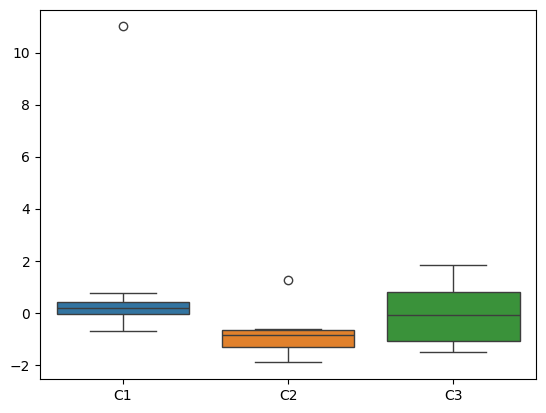

In [47]:
sns.boxplot(data=df)

## 데이터프레임.corr()
- 열들 사이의 상관계수 (-1~1)를 계산한 표
- 1에 가까우면 강한 양의 상관관계
- -1에 가까우면 강한 음의 상관관계
- heatmap 그래프로 상관관계를 표현할 수 있다.
    - annot = True : 히트맵의 각 칸에 실제 상관계수 숫자를 함께 표시해준다.

In [48]:
df.corr()

,C1,C2,C3
C1,1.000000,-0.059442,-0.429005
C2,-0.059442,1.000000,-0.222472
C3,-0.429005,-0.222472,1.000000


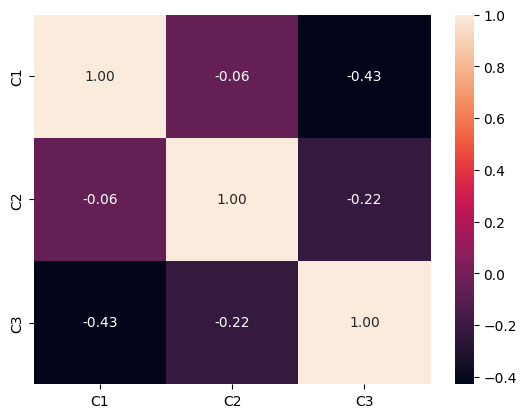

In [50]:
sns.heatmap(df.corr(), annot= True, fmt='.2f')
plt.show()

## 연습문제 1

In [53]:
import pandas as pd
data = {'Name':['Amy','Bob','Chad','Dave','Eva','Fay'],
        'Age':[25,30,35,40,45,50],
        'Gender':['Female','Male','Male','Male','Female','Female'],
        'Salary':[40000,50000,60000,70000,80000,90000]}

df = pd.DataFrame(data=data)

In [54]:
gender_dict = {'Female':0,'Male':1}
df['Gender'] = df['Gender'].apply(lambda x: gender_dict[x])

df

,Name,Age,Gender,Salary
0,Amy,25,0,40000
1,Bob,30,1,50000
2,Chad,35,1,60000
3,Dave,40,1,70000
4,Eva,45,0,80000
5,Fay,50,0,90000


In [56]:
df['Salary'] = df['Salary']//1000
df

,Name,Age,Gender,Salary
0,Amy,25,0,40
1,Bob,30,1,50
2,Chad,35,1,60
3,Dave,40,1,70
4,Eva,45,0,80
5,Fay,50,0,90


In [57]:
df=df.drop('Name', axis=1)
df

,Age,Gender,Salary
0,25,0,40
1,30,1,50
2,35,1,60
3,40,1,70
4,45,0,80
5,50,0,90


## 연습문제 2

In [65]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [66]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [67]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

In [68]:
df.fillna(0)
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64

## 연습문제 3

In [69]:
import pandas as pd

df = pd.read_csv('./연습문제10-4.csv')
df

,dt,AverageTemperature,City,Latitude,Longitude
0,1849-01-01,26.704,Abidjan,5.63N,3.23W
1,1849-02-01,27.434,Abidjan,5.63N,3.23W
2,1849-03-01,28.101,Abidjan,5.63N,3.23W
3,1849-04-01,26.140,Abidjan,5.63N,3.23W
4,1849-05-01,25.427,Abidjan,5.63N,3.23W
...,...,...,...,...,...
239172,2013-05-01,18.979,Xian,34.56N,108.97E
239173,2013-06-01,23.522,Xian,34.56N,108.97E
239174,2013-07-01,25.251,Xian,34.56N,108.97E
239175,2013-08-01,24.528,Xian,34.56N,108.97E


In [70]:
# dt 컬럼 데이터타입 변경
df['dt'] = df['dt'].apply(pd.to_datetime)

df

,dt,AverageTemperature,City,Latitude,Longitude
0,1849-01-01,26.704,Abidjan,5.63N,3.23W
1,1849-02-01,27.434,Abidjan,5.63N,3.23W
2,1849-03-01,28.101,Abidjan,5.63N,3.23W
3,1849-04-01,26.140,Abidjan,5.63N,3.23W
4,1849-05-01,25.427,Abidjan,5.63N,3.23W
...,...,...,...,...,...
239172,2013-05-01,18.979,Xian,34.56N,108.97E
239173,2013-06-01,23.522,Xian,34.56N,108.97E
239174,2013-07-01,25.251,Xian,34.56N,108.97E
239175,2013-08-01,24.528,Xian,34.56N,108.97E


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239177 entries, 0 to 239176
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   dt                  239177 non-null  datetime64[us]
 1   AverageTemperature  228175 non-null  float64       
 2   City                239177 non-null  str           
 3   Latitude            239177 non-null  str           
 4   Longitude           239177 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 9.1 MB


In [73]:
df.isna().sum()

dt                        0
AverageTemperature    11002
City                      0
Latitude                  0
Longitude                 0
dtype: int64

In [74]:
df['AverageTemperature'] = df['AverageTemperature'].fillna(df['AverageTemperature'].mean())
df

,dt,AverageTemperature,City,Latitude,Longitude
0,1849-01-01,26.704000,Abidjan,5.63N,3.23W
1,1849-02-01,27.434000,Abidjan,5.63N,3.23W
2,1849-03-01,28.101000,Abidjan,5.63N,3.23W
3,1849-04-01,26.140000,Abidjan,5.63N,3.23W
4,1849-05-01,25.427000,Abidjan,5.63N,3.23W
...,...,...,...,...,...
239172,2013-05-01,18.979000,Xian,34.56N,108.97E
239173,2013-06-01,23.522000,Xian,34.56N,108.97E
239174,2013-07-01,25.251000,Xian,34.56N,108.97E
239175,2013-08-01,24.528000,Xian,34.56N,108.97E


In [75]:
df.isna().sum()

dt                    0
AverageTemperature    0
City                  0
Latitude              0
Longitude             0
dtype: int64

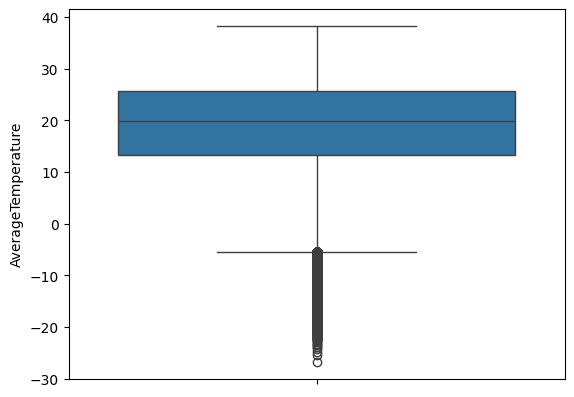

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(df['AverageTemperature'])
plt.show()